# Taxi Trip Fare Prediction

**Predicting taxi trip fares using Linear Regression and tree-based models**

---

| Detail | Value |
|--------|-------|
| **Dataset** | Taxi Trip Pricing Dataset |
| **Techniques** | Linear Regression, Decision Tree Regression, Feature Engineering, EDA |
| **Author** | Ahmed Alnahrawy |



## 1. Setup & Data Loading

Import libraries and load the taxi trip dataset.


In [126]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


In [127]:
df=pd.read_csv('../data/taxi_trip_pricing.csv')
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180



## 2. Exploratory Data Analysis

Explore trip distances, durations, and fare distributions.


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [129]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [130]:
dups = df.duplicated().sum()
print(f"Count of duplicates: {dups}")

Count of duplicates: 0


In [131]:
na_columns = df.columns[df.isnull().sum() > 0]

df[na_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB



## 3. Feature Engineering

Create new features from trip metadata and clean outliers.


In [132]:

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())


for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

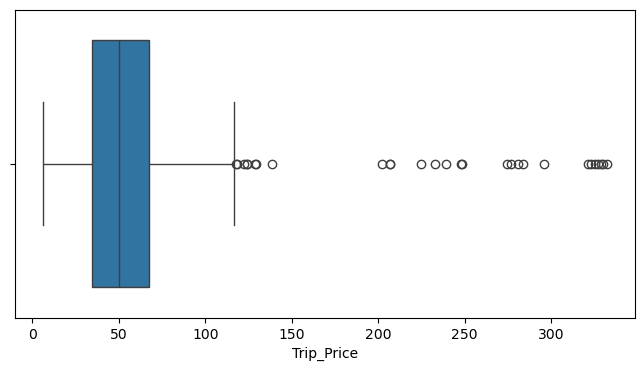

In [133]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Trip_Price'])
plt.show()

In [134]:
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
df = pd.get_dummies(df,columns=cat_cols, drop_first=True,dtype=int)
df.head()


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,0,1,0,0,1,0,0,0
1,47.59,1.0,3.52,0.62,0.43,40.57,50.0745,0,0,0,0,0,0,0,0
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,1,0,0,1,0,0,0,0
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,1,0,0,0,1,0,0,0
4,25.83,3.0,2.93,0.63,0.32,22.64,15.6180,1,0,0,0,0,0,0,0


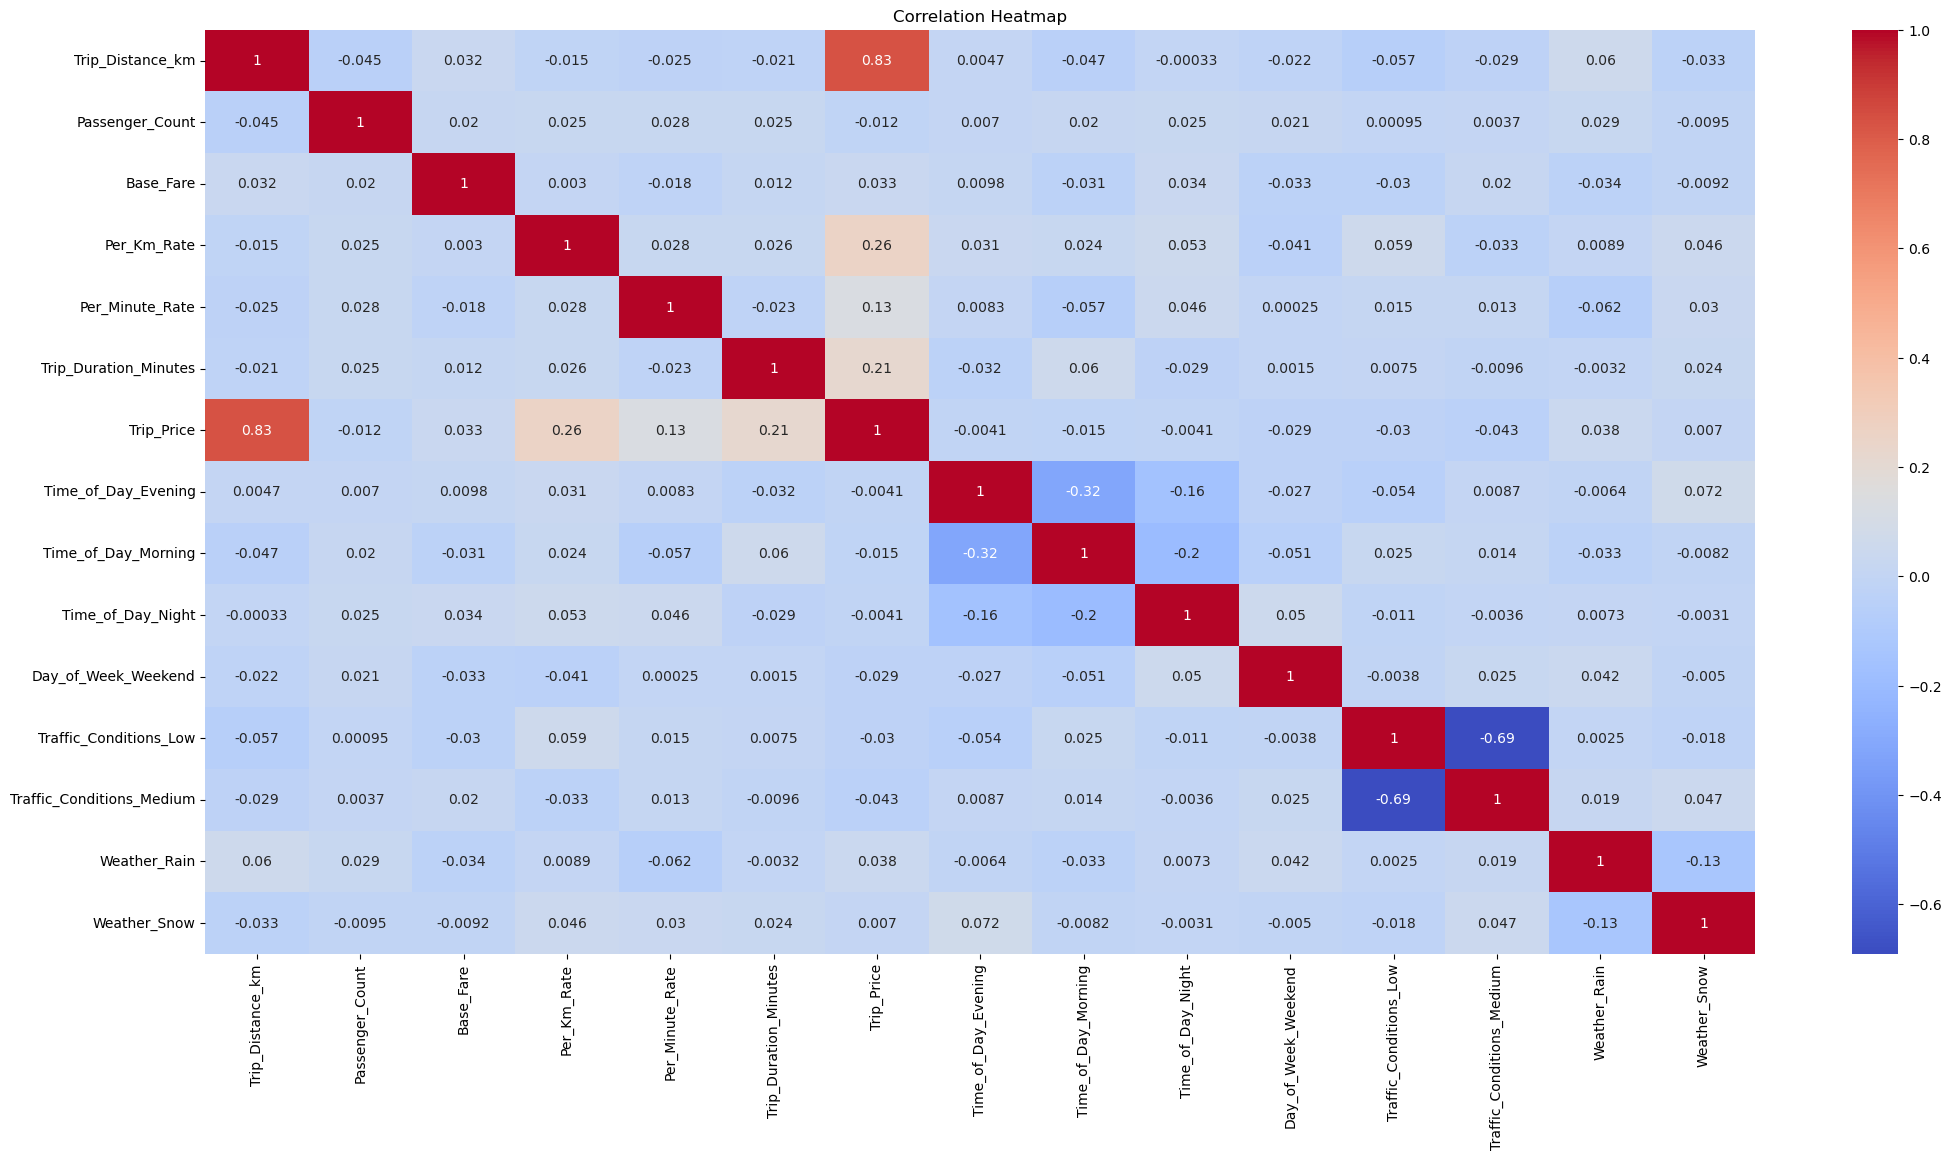

In [135]:

plt.figure(figsize=(25, 12))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.title("Correlation Heatmap")
plt.show()


## 4. Regression Modeling

Train regression models and compare performance metrics.


In [136]:

X = df.drop('Trip_Price', axis=1)
y = df['Trip_Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [137]:

from sklearn.preprocessing import RobustScaler


scaler = RobustScaler()


X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [138]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)

In [139]:


mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Accuracy (R-Squared):", round(r2, 4))

Mean Absolute Error (MAE): 9.7983
Accuracy (R-Squared): 0.7687



---

## Summary

This notebook demonstrated linear regression, decision tree regression, feature engineering, eda techniques applied to the Taxi Trip Pricing Dataset.

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
